<a href="https://colab.research.google.com/github/heramb-sharma-19/Innovexis-Internship/blob/main/Real_Estate_Project_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Real Estate Investment Advisor: Prediciting Property Profitability & Future Value:-**
### *Project Type-* EDA/Regression/Classification/Supervised
### Submitted By:- Heramb Sharma ###

# **Project Summary:-**

The Real Estate Investment Advisor is a machine learning project designed to transform how investors evaluate the Indian property market. The project seamlessly integrates rigorous data science workflows with an intuitive, highly aesthetic web application to provide deep, actionable insights into property valuation and risk assessment. The project begins with a data engineering pipeline. It ingests a comprehensive dataset of Indian housing records and rigorously cleans it by resolving missing data points using statistical medians and modes. Beyond simple cleaning, the pipeline intelligently engineers critical features such as Price per SqFt and establishes two sophisticated target variables. The first is a dynamic classification target that determines whether a property is a "Good Investment" by comparing its price to the locality's historical benchmark and factoring in the property's age. The second is a regression target forecasting the property's exact value five years into the future. It smartly adapts the annual appreciation rate, allocating an aggressive 10% growth rate to booming financial and IT hubs like Mumbai, Bengaluru, and Pune, compared to a standard 8% for other regions. Following thorough Exploratory Data Analysis (EDA) that visually maps out property price distributions, feature correlations, and top city trends, the project trains advanced machine learning models (saved and tracked using MLflow). The resulting predictive engine features both a regression model for precise future price estimation and a classification model to categorize investment safety. All of this backend complexity is abstracted away behind a stunning, user-friendly Streamlit front-end dashboard. The interface is meticulously designed with a modern, premium, vibrant color gradients, and responsive visual feedback. Users can effortlessly input their property specifications and immediately receive dual AI-driven insights: a definitive verdict on whether the property is a lucrative asset or a highly overvalued risk, alongside a concrete projection of the financial return over the next five years. Ultimately, this project is not just a predictive script; it is an end-to-end investment strategy platform. It refines chaotic market data through advanced AI models and presents the conclusions in a beautiful, commercially viable dashboard—empowering everyday investors to make confident, data-driven decisions.



# **GitHub Link:-** #


# **Problem Statement:-** #
### Develop a machine learning application to assist potential investors in making real estate decisions. The system should:
1.	Classify whether a property is a "Good Investment" (Classification).
2.	Predict the estimated property price after 5 years (Regression).


## ***1. Know Your Data***
### Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, classification_report
import xgboost as xgb
import pickle

import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [16]:
# Loading the dataset
df = pd.read_csv('india_housing_prices.csv')
print("Dataset Head:")
df.head()

Dataset Head:


,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


## ***2. Data Pre-processing & Feature Engineering***
### Handling Missing Values & Duplicates

In [17]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Fill missing numericals with median
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Fill missing categoricals with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

### Target Variable Engineering

In [18]:
# Clean text columns
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

# 1. Regression Target: Future Price after 5 years (Base growth 8%, High growth 10%)
high_growth_cities = ['mumbai', 'bangalore', 'bengaluru', 'pune', 'hyderabad']
def calculate_future_price(row):
    rate = 0.10 if row['City'] in high_growth_cities else 0.08
    return row['Price_in_Lakhs'] * ((1 + rate) ** 5)
df['Future_Price_5Y_Lakhs'] = df.apply(calculate_future_price, axis=1)

# 2. Classification Target: Good Investment (Cheaper than local median & Age < 15)
median_price_locality = df.groupby('Locality')['Price_per_SqFt'].transform('median')
median_price_city = df.groupby('City')['Price_per_SqFt'].transform('median')
benchmark_price = median_price_locality.fillna(median_price_city)

df['Benchmark_Price'] = benchmark_price
df['Good_Investment'] = df.apply(lambda row: 1 if (row['Price_per_SqFt'] <= row['Benchmark_Price']) and (row['Age_of_Property'] < 15) else 0, axis=1)
df.drop(columns=['Benchmark_Price'], inplace=True)

### Categorical Encoding

In [27]:
# Store fitted encoders in a dictionary
fitted_encoders = {}

# Drop 'ID' if it exists before processing
if 'ID' in df.columns:
    df.drop(columns=['ID'], inplace=True)

# Get current categorical columns (after 'ID' drop)
current_cat_cols = df.select_dtypes(include=['object']).columns

for col in current_cat_cols:
    le = LabelEncoder()
    df[col+'_encoded'] = le.fit_transform(df[col])
    fitted_encoders[col] = le # Save the fitted encoder

## ***3. Exploratory Data Analysis (EDA)***

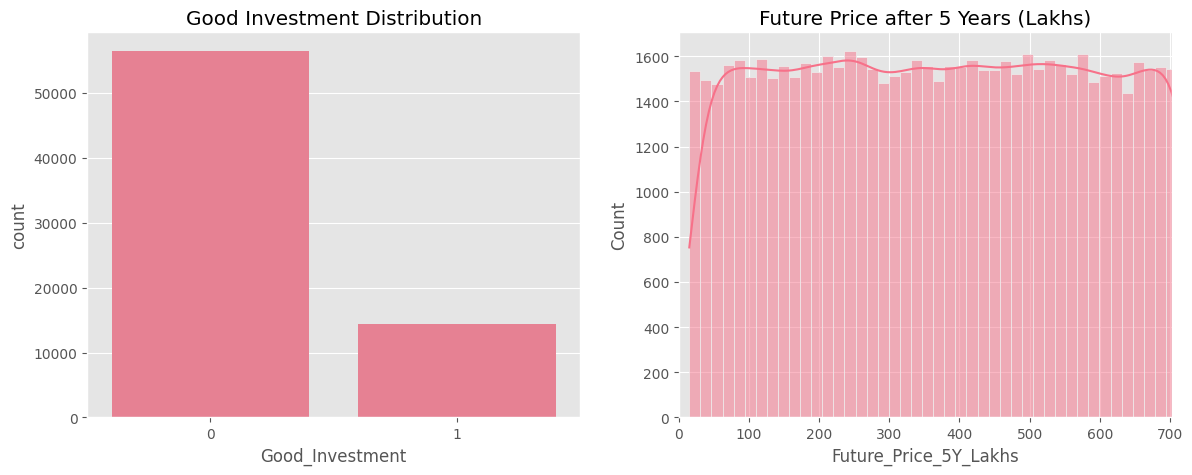

In [20]:
plt.style.use('ggplot')
sns.set_palette('husl')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='Good_Investment', data=df, ax=axes[0])
axes[0].set_title('Good Investment Distribution')

sns.histplot(df['Future_Price_5Y_Lakhs'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Future Price after 5 Years (Lakhs)')
axes[1].set_xlim(0, df['Future_Price_5Y_Lakhs'].quantile(0.95))
plt.show()

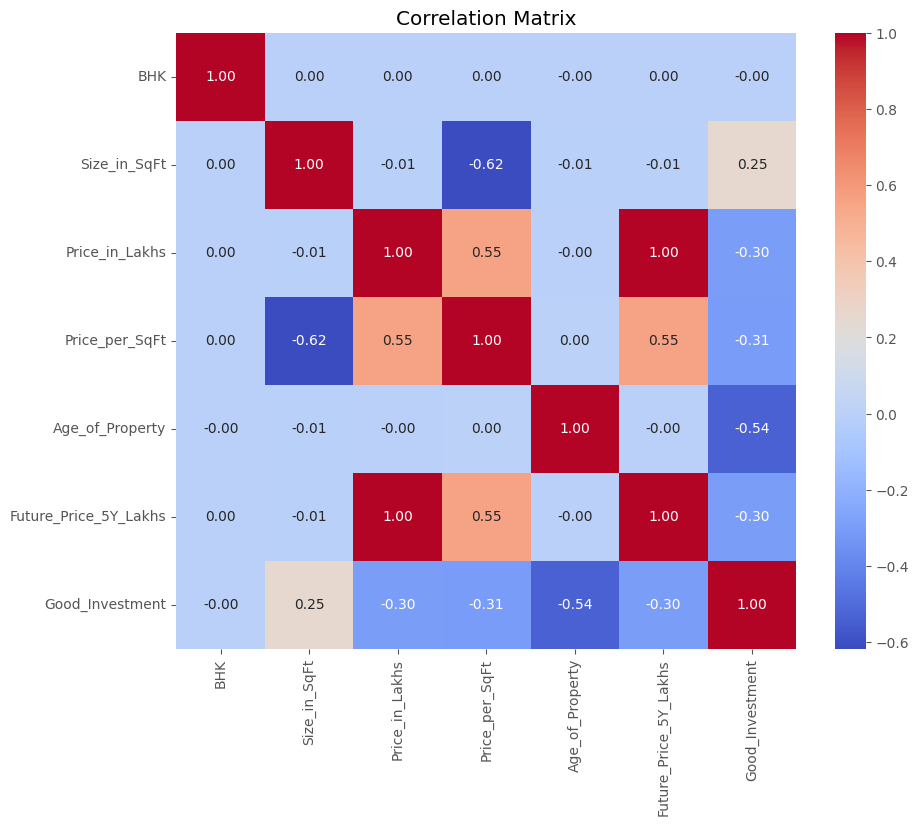

In [21]:
plt.figure(figsize=(10, 8))
cols_to_use = ['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Age_of_Property', 'Future_Price_5Y_Lakhs', 'Good_Investment']
corr = df[[c for c in cols_to_use if c in df.columns]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## ***4. ML Model Implementation***
### Data Splitting

In [22]:
cat_cols = df.select_dtypes(include=['object']).columns
targets = ['Future_Price_5Y_Lakhs', 'Good_Investment', 'Price_in_Lakhs', 'Price_per_SqFt']
features_df = df.drop(columns=list(cat_cols) + targets)

X = features_df

# Regression and Classification Target Splits
y_reg = df['Future_Price_5Y_Lakhs']
y_clf = df['Good_Investment']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_clf, test_size=0.2, random_state=42)

### Model 1: XGBoost Regressor (Future Price Prediction)

In [24]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.5/857.5 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [25]:
import mlflow
import mlflow.xgboost

# Set MLflow tracking URI (optional, default is local './mlruns')
# mlflow.set_tracking_uri("http://localhost:5000")

# Start an MLflow run
with mlflow.start_run(run_name="XGBoost_Regression_Model"):
    # Define and log model parameters
    n_estimators = 100
    learning_rate = 0.1
    random_state = 42
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("random_state", random_state)

    reg_model = xgb.XGBRegressor(n_estimators=n_estimators, learning_rate=learning_rate, random_state=random_state)
    reg_model.fit(X_train_r, y_train_r)
    preds_r = reg_model.predict(X_test_r)

    # Calculate and log metrics
    rmse = np.sqrt(mean_squared_error(y_test_r, preds_r))
    r2 = r2_score(y_test_r, preds_r)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2_score", r2)

    # Log the model
    mlflow.xgboost.log_model(reg_model, "xgboost_reg_model")

    print(f"Regression RMSE: {rmse:.2f}")
    print(f"Regression R2 Score: {r2:.4f}")
    print(f"MLflow Run ID: {mlflow.active_run().info.run_id}")

2026/04/20 10:05:14 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/20 10:05:14 INFO mlflow.store.db.utils: Updating database tables
2026/04/20 10:05:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Regression RMSE: 210.34
Regression R2 Score: -0.0098
MLflow Run ID: 08af0aaeddc94a9e9e7fb75dafcff491


### Model 2: XGBoost Classifier (Good Investment Prediction)

In [26]:
import mlflow
import mlflow.xgboost

# Start an MLflow run for the classifier
with mlflow.start_run(run_name="XGBoost_Classification_Model"):
    # Define and log model parameters
    n_estimators = 100
    learning_rate = 0.1
    random_state = 42
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("random_state", random_state)

    clf_model = xgb.XGBClassifier(n_estimators=n_estimators, learning_rate=learning_rate, random_state=random_state)
    clf_model.fit(X_train_c, y_train_c)
    preds_c = clf_model.predict(X_test_c)

    # Calculate and log metrics
    accuracy = accuracy_score(y_test_c, preds_c)
    f1 = f1_score(y_test_c, preds_c, average='weighted')
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("f1_score", f1)

    # Log the model
    mlflow.xgboost.log_model(clf_model, "xgboost_clf_model")

    print(f"Classification Accuracy: {accuracy:.4f}")
    print(f"Classification F1: {f1:.4f}")
    print(classification_report(y_test_c, preds_c))
    print(f"MLflow Run ID: {mlflow.active_run().info.run_id}")

2026/04/20 10:09:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Classification Accuracy: 0.8945
Classification F1: 0.8948
              precision    recall  f1-score   support

           0       0.94      0.93      0.93     11297
           1       0.74      0.75      0.74      2871

    accuracy                           0.89     14168
   macro avg       0.84      0.84      0.84     14168
weighted avg       0.90      0.89      0.89     14168

MLflow Run ID: fc99cb6f4e944841ada7187c184c976f


## ***5. Future Work & Deployment***
Save the final models sequentially so Streamlit can utilize them.

In [28]:
import os
import pickle

if not os.path.exists('models'):
    os.makedirs('models')

with open('models/reg_model.pkl', 'wb') as f:
    pickle.dump(reg_model, f)

with open('models/clf_model.pkl', 'wb') as f:
    pickle.dump(clf_model, f)

with open('models/features.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

# Save the fitted_encoders dictionary
with open('models/encoders.pkl', 'wb') as f:
    pickle.dump(fitted_encoders, f)

print("Models and encoders efficiently cached to models/")

Models and encoders efficiently cached to models/


In [29]:
%%writefile streamlit_app.py

import streamlit as st
import pandas as pd
import numpy as np
import pickle
import os

st.set_page_config(layout="wide", page_title="Real Estate Investment Advisor")

# --- Constants ---
HIGH_GROWTH_CITIES = ['mumbai', 'bangalore', 'bengaluru', 'pune', 'hyderabad']

# --- Helper Functions ---
@st.cache_resource
def load_model_and_artifacts():
    models_path = 'models'
    reg_model = pickle.load(open(os.path.join(models_path, 'reg_model.pkl'), 'rb'))
    clf_model = pickle.load(open(os.path.join(models_path, 'clf_model.pkl'), 'rb'))
    features = pickle.load(open(os.path.join(models_path, 'features.pkl'), 'rb'))
    encoders = pickle.load(open(os.path.join(models_path, 'encoders.pkl'), 'rb'))
    return reg_model, clf_model, features, encoders

reg_model, clf_model, features, encoders = load_model_and_artifacts()

def preprocess_input(input_df, features, encoders):
    processed_data = pd.DataFrame(index=[0])

    for feature in features:
        if feature in input_df.columns:
            processed_data[feature] = input_df[feature].values[0]
        else:
            # Handle features not directly from user input (e.g., encoded categoricals)
            if feature.endswith('_encoded'):
                original_col = feature.replace('_encoded', '')
                if original_col in input_df.columns and original_col in encoders:
                    # Ensure input value is in lower case for consistent encoding
                    val = input_df[original_col].values[0].lower()
                    encoder = encoders[original_col]
                    try:
                        processed_data[feature] = encoder.transform([val])[0]
                    except ValueError:
                        # Handle unseen labels by assigning a default or mode, for now using 0
                        processed_data[feature] = 0 # Or any other appropriate default
                else:
                    processed_data[feature] = 0 # Default for missing encoded features
            else:
                processed_data[feature] = 0 # Default for other missing features

    return processed_data

# --- Streamlit App ---
st.title("🇮🇳 Real Estate Investment Advisor")
st.markdown("### Predict Property Profitability & Future Value")

st.subheader("Property Details Input")

# Organize input into columns
col1, col2, col3 = st.columns(3)

with col1:
    state = st.selectbox("State", options=[enc.lower() for enc in encoders['State'].classes_])
    city = st.selectbox("City", options=[enc.lower() for enc in encoders['City'].classes_])
    locality = st.selectbox("Locality", options=[enc.lower() for enc in encoders['Locality'].classes_])
    property_type = st.selectbox("Property Type", options=[enc.lower() for enc in encoders['Property_Type'].classes_])
    bhk = st.slider("BHK", 1, 10, 2)

with col2:
    size_sqft = st.number_input("Size in SqFt", min_value=100, max_value=50000, value=1200)
    year_built = st.slider("Year Built", 1900, 2024, 2000)
    floor_no = st.slider("Floor Number", 0, 50, 1)
    total_floors = st.slider("Total Floors", 1, 100, 5)
    furnished_status = st.selectbox("Furnished Status", options=[enc.lower() for enc in encoders['Furnished_Status'].classes_])

with col3:
    nearby_schools = st.slider("Nearby Schools (km)", 0, 20, 2)
    nearby_hospitals = st.slider("Nearby Hospitals (km)", 0, 20, 2)
    public_transport = st.selectbox("Public Transport Accessibility", options=[enc.lower() for enc in encoders['Public_Transport_Accessibility'].classes_])
    parking_space = st.selectbox("Parking Space", options=[enc.lower() for enc in encoders['Parking_Space'].classes_])
    security = st.selectbox("Security", options=[enc.lower() for enc in encoders['Security'].classes_])
    facing = st.selectbox("Facing", options=[enc.lower() for enc in encoders['Facing'].classes_])
    owner_type = st.selectbox("Owner Type", options=[enc.lower() for enc in encoders['Owner_Type'].classes_])
    availability_status = st.selectbox("Availability Status", options=[enc.lower() for enc in encoders['Availability_Status'].classes_])
    # price_in_lakhs = st.number_input("Current Price in Lakhs (for benchmark)", min_value=1.0, max_value=10000.0, value=50.0)

# Create a dictionary from inputs
input_data = {
    'State': state,
    'City': city,
    'Locality': locality,
    'Property_Type': property_type,
    'BHK': bhk,
    'Size_in_SqFt': size_sqft,
    'Year_Built': year_built,
    'Floor_No': floor_no,
    'Total_Floors': total_floors,
    'Furnished_Status': furnished_status,
    'Nearby_Schools': nearby_schools,
    'Nearby_Hospitals': nearby_hospitals,
    'Public_Transport_Accessibility': public_transport,
    'Parking_Space': parking_space,
    'Security': security,
    'Facing': facing,
    'Owner_Type': owner_type,
    'Availability_Status': availability_status,
    # 'Price_in_Lakhs': price_in_lakhs, # Not used as input for prediction directly, calculated if needed
}

# Add derived features needed for encoding but not directly in `X`
input_data['Age_of_Property'] = 2025 - year_built # Assuming current year for age calculation

# Create a DataFrame from input data
input_df = pd.DataFrame([input_data])

# Preprocess input for models
processed_input = preprocess_input(input_df, features, encoders)

# Make predictions
if st.button("Predict"):
    # Classification Prediction
    clf_prediction = clf_model.predict(processed_input)
    is_good_investment = "Yes" if clf_prediction[0] == 1 else "No"

    # Regression Prediction
    # Calculate Price_in_Lakhs for future price calculation if needed,
    # but reg_model uses its own features derived from input.
    # The original notebook derived Future_Price_5Y_Lakhs from Price_in_Lakhs directly.
    # Here we directly predict it using the features X.
    future_price_pred = reg_model.predict(processed_input)[0]

    st.subheader("Prediction Results")

    colA, colB = st.columns(2)

    with colA:
        st.success(f"**Good Investment (Classification):** {is_good_investment}")
        if is_good_investment == "Yes":
            st.balloons()
        else:
            st.warning("Consider other options or re-evaluate criteria.")

    with colB:
        st.info(f"**Estimated Future Price (5 Years):** ₹{future_price_pred:,.2f} Lakhs")
        st.markdown("*(Note: This is a direct prediction based on the trained regression model.)*")


st.markdown("""
---
### How to Run this Streamlit App:
1. Save the code above as `streamlit_app.py` in your working directory.
2. Open your terminal or command prompt.
3. Navigate to the directory where you saved the file.
4. Run the command: `streamlit run streamlit_app.py`
5. The app will open in your web browser.
""")

Writing streamlit_app.py
